In [26]:
from utils_features import *
import pandas as pd
import mplfinance as mpf
import numpy as np

In [ ]:
df_gc_dia = import_dataset()
df_gc_dia.head()

,DTYYYYMMDD,OPEN,HIGH,LOW,CLOSE,VOL,OPENINT,DATETIME
count,12253,12253.000000,12253.000000,12253.000000,12253.000000,12253.000000,12253.000000,12253
mean,1999-05-16 20:24:56.058108288,703.610854,708.671395,698.269820,703.584975,74866.384477,113803.318453,1999-05-16 20:24:56.058108288
min,1974-12-31 00:00:00,101.500000,102.800000,100.000000,102.800000,0.000000,0.000000,1974-12-31 00:00:00
25%,1987-03-09 00:00:00,338.900000,340.800000,337.300000,339.000000,15234.000000,0.000000,1987-03-09 00:00:00
50%,1999-05-12 00:00:00,411.000000,414.000000,408.000000,411.300000,31771.000000,0.000000,1999-05-12 00:00:00
75%,2011-08-01 00:00:00,1197.700000,1206.400000,1188.100000,1197.500000,122243.000000,242350.000000,2011-08-01 00:00:00
max,2023-09-19 00:00:00,2076.400000,2089.200000,2049.000000,2075.200000,787217.000000,553207.000000,2023-09-19 00:00:00
std,NaN,528.272038,532.295990,523.824694,528.178438,90672.545487,150009.439800,NaN


In [ ]:
df_gc_dia.describe()

,DTYYYYMMDD,OPEN,HIGH,LOW,CLOSE,VOL,OPENINT,DATETIME
count,12253,12253.000000,12253.000000,12253.000000,12253.000000,12253.000000,12253.000000,12253
mean,1999-05-16 20:24:56.058108288,703.610854,708.671395,698.269820,703.584975,74866.384477,113803.318453,1999-05-16 20:24:56.058108288
min,1974-12-31 00:00:00,101.500000,102.800000,100.000000,102.800000,0.000000,0.000000,1974-12-31 00:00:00
25%,1987-03-09 00:00:00,338.900000,340.800000,337.300000,339.000000,15234.000000,0.000000,1987-03-09 00:00:00
50%,1999-05-12 00:00:00,411.000000,414.000000,408.000000,411.300000,31771.000000,0.000000,1999-05-12 00:00:00
75%,2011-08-01 00:00:00,1197.700000,1206.400000,1188.100000,1197.500000,122243.000000,242350.000000,2011-08-01 00:00:00
max,2023-09-19 00:00:00,2076.400000,2089.200000,2049.000000,2075.200000,787217.000000,553207.000000,2023-09-19 00:00:00
std,NaN,528.272038,532.295990,523.824694,528.178438,90672.545487,150009.439800,NaN


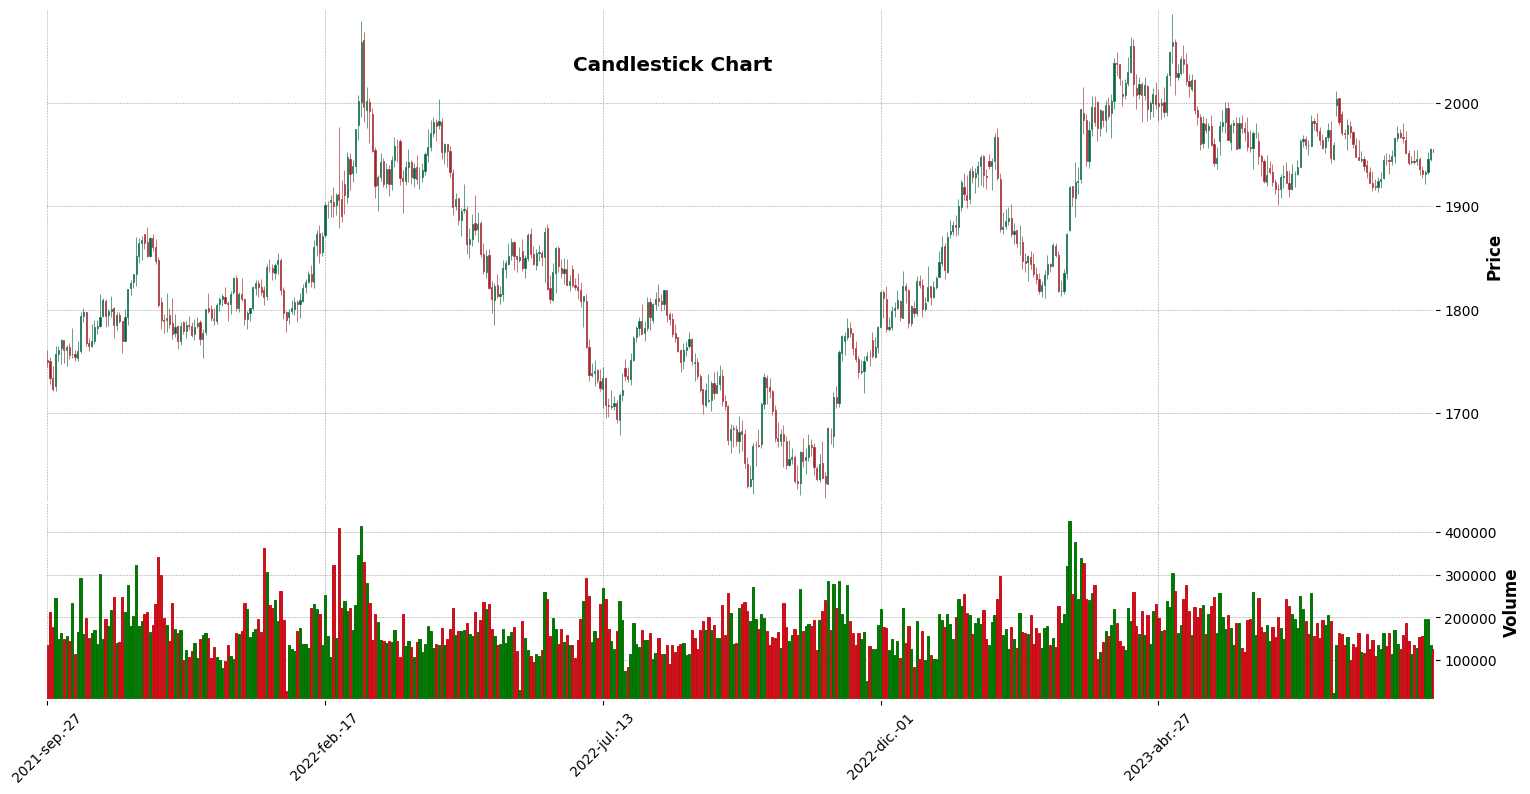

In [22]:
plot_candlestick_chart(df_gc_dia)

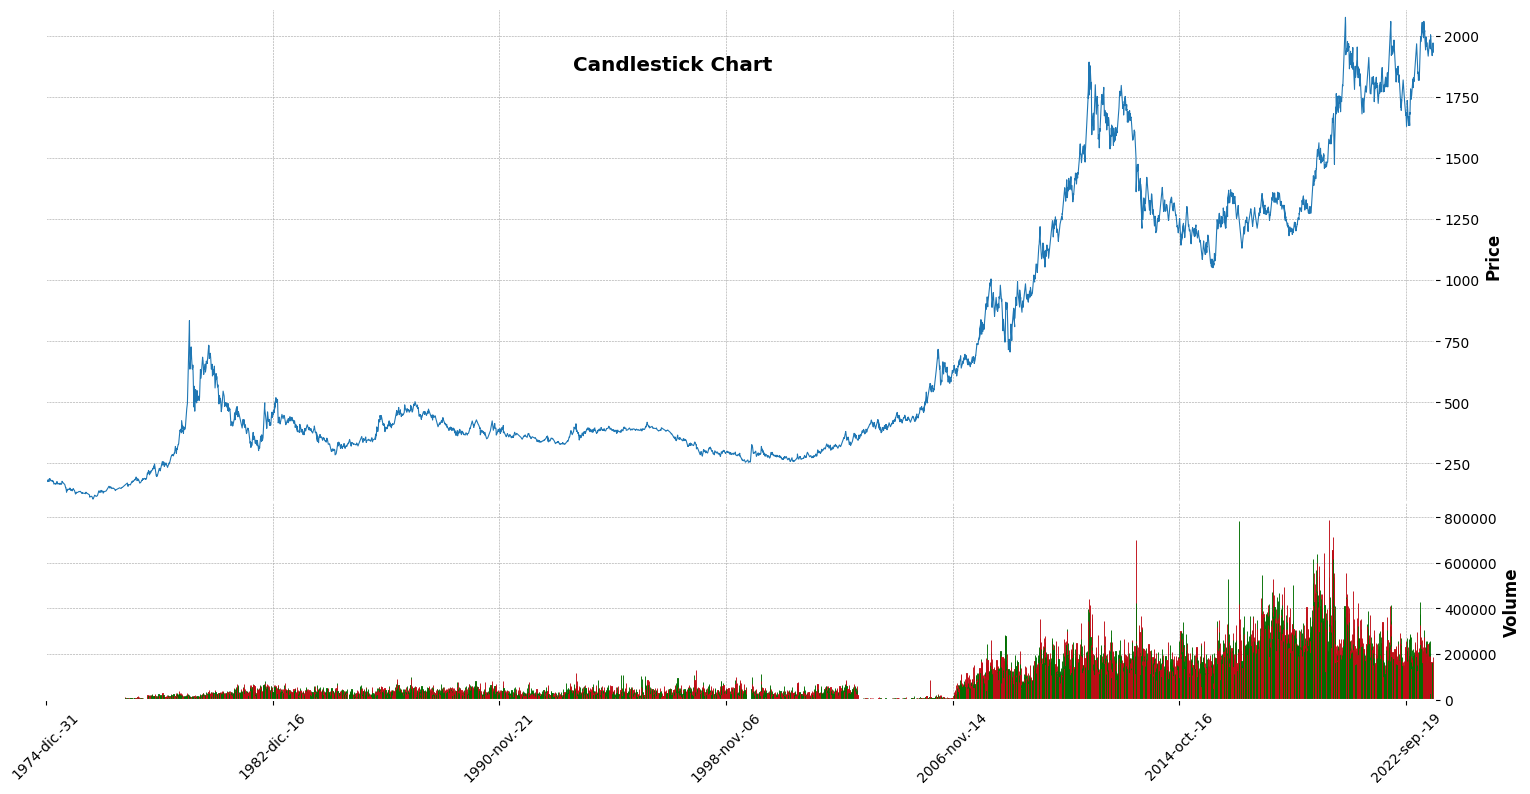

In [23]:
plot_candlestick_chart(df_gc_dia, full_dataset=True)


In [25]:
df = df_gc_dia.copy()

In [27]:
def create_features(df):
    features = df.copy()
    
    # Retornos básicos
    features['Return'] = features['CLOSE'].pct_change()
    features['LogReturn'] = np.log(features['CLOSE']/features['CLOSE'].shift(1))
    
    # OHLC ratios
    features['HL_Ratio'] = features['HIGH']/features['LOW']
    features['CO_Pct'] = (features['CLOSE']-features['OPEN'])/features['OPEN']
    
    # Momentum
    for period in [5,10,20]:
        features[f'SMA_{period}'] = features['CLOSE'].rolling(period).mean()
        features[f'Return_{period}'] = features['CLOSE'].pct_change(period)
    
    # Volatilidad
    features['Vol_10'] = features['LogReturn'].rolling(10).std()
    features['Vol_20'] = features['LogReturn'].rolling(20).std()
    
    # Volumen
    features['Vol_SMA'] = features['VOL'].rolling(20).mean()
    features['Vol_Ratio'] = features['VOL']/features['Vol_SMA']
    
    return features.dropna()

In [28]:
create_features(df)

,TICKER,PER,DTYYYYMMDD,TIME,OPEN,HIGH,LOW,CLOSE,VOL,OPENINT,...,SMA_5,Return_5,SMA_10,Return_10,SMA_20,Return_20,Vol_10,Vol_20,Vol_SMA,Vol_Ratio
20,GC,D,1975-01-29,00:00:00,180.0,181.7,179.6,181.7,1380,0,...,180.16,0.027134,178.53,0.009444,179.065,-0.011963,0.015822,0.015313,972.60,1.418877
21,GC,D,1975-01-30,00:00:00,179.7,180.7,178.0,178.3,195,0,...,180.04,-0.003354,178.59,0.003376,179.070,0.000561,0.016507,0.014194,938.95,0.207679
22,GC,D,1975-01-31,00:00:00,178.0,178.4,177.0,178.0,907,0,...,179.20,-0.023052,178.92,0.018890,179.095,0.002817,0.015389,0.014170,952.65,0.952081
23,GC,D,1975-02-03,00:00:00,179.1,179.7,178.1,178.3,668,0,...,178.98,-0.006132,178.86,-0.003354,179.170,0.008484,0.013349,0.014140,934.75,0.714630
24,GC,D,1975-02-04,00:00:00,176.5,177.5,175.6,177.3,914,0,...,178.72,-0.007279,178.96,0.005672,179.245,0.008532,0.012556,0.014139,927.20,0.985764
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12248,GC,D,2023-09-13,00:00:00,1935.2,1938.4,1927.2,1930.6,156209,402360,...,1939.72,-0.005768,1949.50,-0.017806,1942.560,-0.001397,0.003205,0.004291,141616.50,1.103042
12249,GC,D,2023-09-14,00:00:00,1930.7,1934.5,1921.7,1932.5,196220,402360,...,1937.42,-0.005916,1945.72,-0.019185,1943.080,0.005411,0.003027,0.004076,145189.20,1.351478
12250,GC,D,2023-09-15,00:00:00,1932.5,1952.4,1931.2,1945.2,195342,402360,...,1937.94,0.001338,1943.58,-0.010882,1944.395,0.013706,0.004047,0.004280,147617.80,1.323296
12251,GC,D,2023-09-18,00:00:00,1945.7,1955.7,1943.8,1955.2,134529,402360,...,1939.92,0.005089,1942.48,-0.005595,1946.235,0.019183,0.004503,0.004386,148827.40,0.903926


In [30]:
df

,TICKER,PER,DTYYYYMMDD,TIME,OPEN,HIGH,LOW,CLOSE,VOL,OPENINT,DATETIME
0,GC,D,1974-12-31,00:00:00,191.0,191.5,182.7,183.9,512,0,1974-12-31
1,GC,D,1975-01-02,00:00:00,186.0,187.5,176.0,178.2,868,0,1975-01-02
2,GC,D,1975-01-03,00:00:00,175.5,178.5,172.5,177.5,633,0,1975-01-03
3,GC,D,1975-01-06,00:00:00,175.0,177.2,169.0,176.8,1026,0,1975-01-06
4,GC,D,1975-01-07,00:00:00,173.0,176.5,171.5,175.8,1065,0,1975-01-07
...,...,...,...,...,...,...,...,...,...,...,...
12248,GC,D,2023-09-13,00:00:00,1935.2,1938.4,1927.2,1930.6,156209,402360,2023-09-13
12249,GC,D,2023-09-14,00:00:00,1930.7,1934.5,1921.7,1932.5,196220,402360,2023-09-14
12250,GC,D,2023-09-15,00:00:00,1932.5,1952.4,1931.2,1945.2,195342,402360,2023-09-15
12251,GC,D,2023-09-18,00:00:00,1945.7,1955.7,1943.8,1955.2,134529,402360,2023-09-18
